In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv('Online Retail.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
data = df[['Quantity', 'UnitPrice']].copy()
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]
data = data[(data['Quantity'] <= data['Quantity'].quantile(0.99)) &(data['UnitPrice'] <= data['UnitPrice'].quantile(0.99))]
data.head()

,Quantity,UnitPrice
0,6,2.55
1,6,3.39
2,8,2.75
3,6,3.39
4,6,3.39


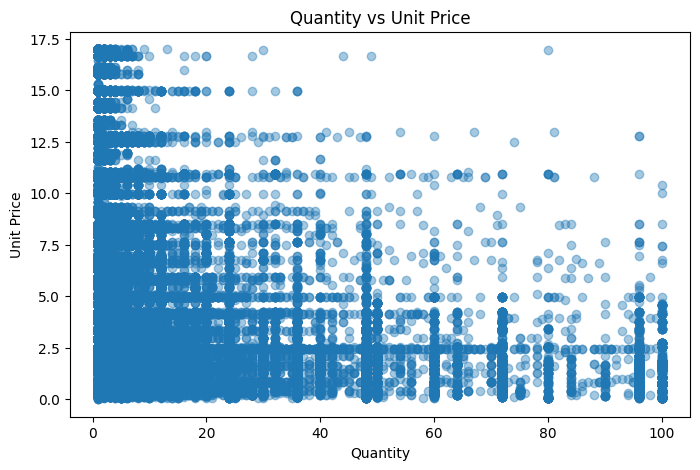

In [14]:
# Plot the data before clustering
plt.figure(figsize=(8, 5))
plt.scatter(data['Quantity'], data['UnitPrice'], alpha=0.4)
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.title('Quantity vs Unit Price')
plt.show()

In [15]:
# Scale the values because Quantity and UnitPrice have different ranges
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

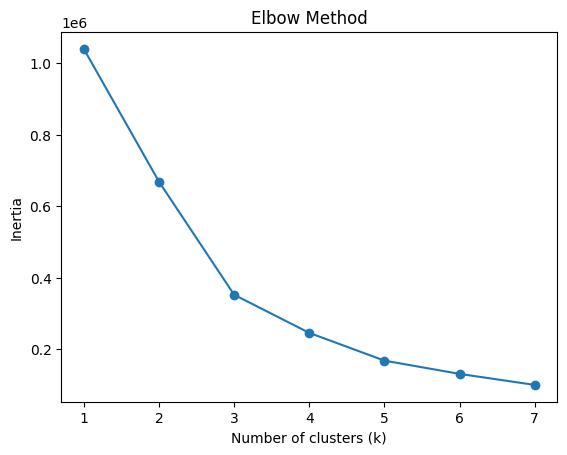

In [16]:
# Elbow method: try different numbers of clusters
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [17]:
# From the elbow plot, choose 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)
data.head()

,Quantity,UnitPrice,Cluster
0,6,2.55,0
1,6,3.39,0
2,8,2.75,0
3,6,3.39,0
4,6,3.39,0


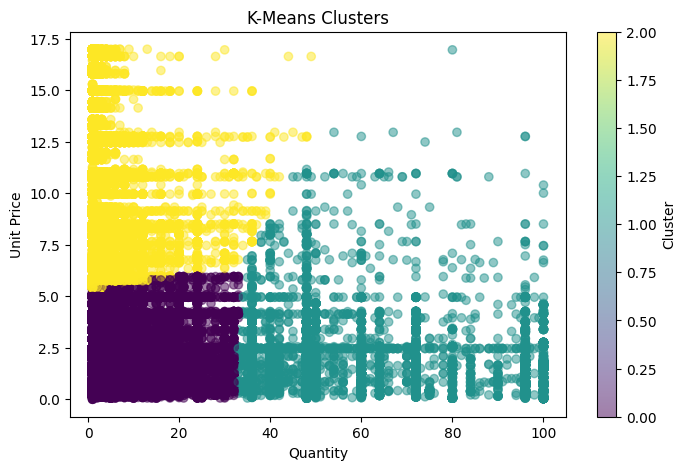

In [18]:
# Final cluster plot
plt.figure(figsize=(8, 5))
plt.scatter(data['Quantity'], data['UnitPrice'], c=data['Cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.title('K-Means Clusters')
plt.colorbar(label='Cluster')
plt.show()